In [1]:
import pandas as pd
df = pd.read_csv("Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
df.isna().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [3]:
df = df.drop(columns=['Channel', 'Region'])
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
col_scale = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]
df[col_scale] = scaler.fit_transform(df[col_scale])
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Try different values of k
k_values = range(1, 11)
inertias = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10
    )

    kmeans.fit(df)   # or X if you don't have train/test split

    inertia = kmeans.inertia_
    inertias.append(inertia)

    print(f"k = {k}, Inertia = {inertia:.2f}")

C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

k = 1, Inertia = 2640.00
k = 2, Inertia = 1954.04
k = 3, Inertia = 1620.30
k = 4, Inertia = 1312.52
k = 5, Inertia = 1058.77
k = 6, Inertia = 915.77
k = 7, Inertia = 822.72
k = 8, Inertia = 736.97
k = 9, Inertia = 666.22
k = 10, Inertia = 609.18


C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


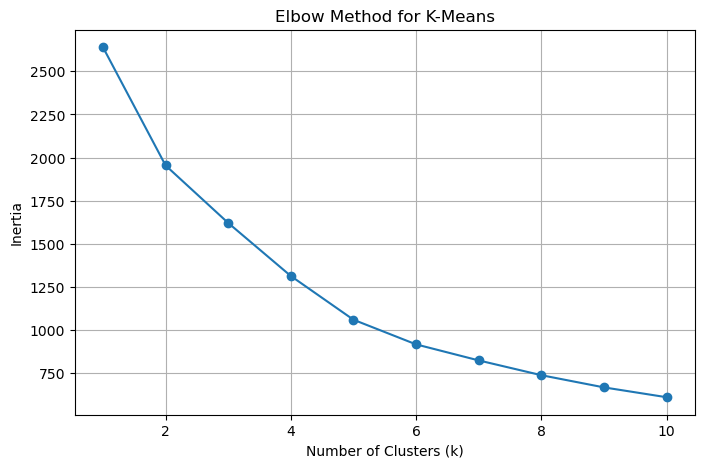

In [17]:
plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

In [20]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10)

kmeans.fit(df)

clusters = kmeans.labels_
clusters

C:\Users\Ahmed\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


array([0, 4, 4, 0, 3, 0, 0, 0, 0, 4, 4, 0, 3, 4, 4, 0, 4, 0, 0, 0, 0, 0,
       3, 4, 4, 0, 0, 0, 4, 3, 0, 0, 0, 3, 0, 4, 3, 4, 4, 3, 3, 0, 4, 4,
       4, 4, 4, 1, 4, 4, 0, 0, 3, 4, 0, 0, 1, 4, 0, 0, 0, 1, 0, 4, 0, 1,
       0, 4, 0, 0, 3, 3, 0, 3, 0, 0, 0, 4, 0, 0, 0, 4, 4, 0, 0, 1, 1, 3,
       0, 3, 0, 0, 1, 3, 4, 0, 0, 0, 0, 0, 4, 4, 0, 3, 0, 0, 4, 4, 0, 4,
       0, 4, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 0, 0, 3, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0, 0, 4, 0, 0, 0, 3, 0, 0, 0, 0,
       0, 4, 4, 0, 0, 4, 4, 0, 0, 4, 0, 4, 4, 0, 0, 0, 4, 4, 0, 4, 0, 4,
       3, 0, 0, 0, 0, 3, 4, 2, 0, 0, 0, 0, 4, 4, 0, 0, 0, 4, 0, 3, 3, 4,
       0, 0, 4, 4, 3, 0, 0, 4, 0, 0, 0, 4, 0, 1, 0, 0, 4, 4, 4, 0, 4, 0,
       0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 0,
       0, 0, 4, 4, 0, 0, 0, 0, 0, 1, 0, 3, 4, 3, 0, 0, 3, 3, 0, 0, 0, 0,
       4, 4, 4, 0, 4, 0, 0, 0, 0, 3, 0, 0, 3, 3, 0, 0, 0, 0, 3, 3, 3, 3,
       0, 0, 0, 3, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0,